# Summary statistics for the dataset

This notebook plots the intial descriptive graphs. 

In [26]:
import pandas as pd
import numpy as np
import math 
import matplotlib.pyplot as plt
import geopandas as gpd

from elasticsearch import Elasticsearch

from database.comments import Comments

import sys
sys.path.append('../functions')
import preprocessing_fncs as ppf
from elastic_search_fncs import ElasticSearchFncs

### Dataset 1 - geo boundaries 
This is the .geojson file of the boundaries of the london authorities. 

In [2]:
london_lad = gpd.read_file('../data/london_geos/Local_Authority_Districts_May_2024_London.geojson')


### Dataset 2 - applications
This is the .csv file extarcted from the Planning London Datahub which was used to identify applications for webscraping. 

In [3]:
# Application dataset 
application_df_path = "/Users/bea/Documents/AI4CI/projects/comment_summariser/comment_summariser/data/PLD_application_ids/all_since21_cleaned.csv"
application_df = pd.read_csv(application_df_path)
print(f"There are {len(application_df)} applications in the dataset.")

# drop 'Bromley' applications -  since I haven't been able to get the comments for these
application_df = application_df[application_df['borough'] != 'Bromley']
print(f"There are {len(application_df)} applications in the dataset after dropping Bromley applications.")

application_df = ppf.format_df(application_df, 'borough')

There are 5850 applications in the dataset.
There are 5077 applications in the dataset after dropping Bromley applications.


### Dataset 3 - comments 
This is the remote database of comments resulting from webscraping. This dataset matches to the planning applications on 'application_id'. 

In [4]:
# Comments dataset
cs = Comments()
comment_df = cs.read_all().copy()
comment_df = ppf.format_borough(comment_df, 'council')

comment_df.head()

Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score
0,79910,Brent,23/2303_10,23/2303,"49 St Gabriels Road, London, NW2 4DT",Objects,2023-09-14,The proposed house is out of keeping with the ...,2025-04-08,51.474668,-0.105307,The proposed house is out of keeping with the ...,E09000022,-0.309787
1,79913,Brent,23/2303_13,23/2303,"45 St Gabriels Road, London, NW2 4DT",Objects,2023-09-12,If the council's planning department allows th...,2025-04-08,51.474668,-0.105307,If the council's planning department allows th...,E09000022,-0.508164
2,74170,Ealing,225185FUL_132,225185FUL,4 Marlborough Road Ealing LONDON W5 5NY W5 5NY,Objects,2023-01-22,The current house at no6 is a major feature of...,2025-04-07,51.505460,-0.301420,The current house at is a major feature of . I...,E09000009,-0.343599
3,89490,Ealing,212170FUL_56,212170FUL,29 Park Place Ealing W5 5NQ W5 5NQ,Objects,2021-09-29,I strongly object to this revised proposal. Co...,2025-04-10,51.508277,-0.303380,I strongly object to this revised proposal. Co...,E09000009,-0.572075
4,89502,Ealing,212170FUL_68,212170FUL,33 Park Place LONDON W5 5NQ W5 5NQ,Objects,2021-09-27,Inappropriate development on a site which is n...,2025-04-10,51.508277,-0.303380,Inappropriate development on a site which is n...,E09000009,-0.629649


In [5]:
print(f"The councils in the dataset are: {comment_df['council'].unique()}")
print(f"Total number of comments: {len(comment_df)}")
print(f"Total number of applications (with comments scraped): {len(comment_df.application_id.unique())}")

The councils in the dataset are: ['Brent' 'Ealing' 'Barnet' 'Newham' 'City of London' 'Southwark' 'Lambeth'
 'Westminster']
Total number of comments: 30393
Total number of applications (with comments scraped): 2453


In [6]:
comment_df.groupby("application_id").size().describe()

count    2453.000000
mean       12.390135
std        42.732741
min         1.000000
25%         1.000000
50%         3.000000
75%         8.000000
max       844.000000
dtype: float64

In [7]:
# Count unique apps and comments per council
comment_stats = (
    comment_df
    .groupby('council')[['application_id', 'comment_id']]
    .nunique()
    .rename(columns={
        'application_id': 'no_applications_with_comments',
        'comment_id': 'total_comment_count'
    })
    .reset_index()
)

# Compute mean comments per application
comment_stats['mean_comments_per_application'] = (
    comment_stats['total_comment_count'] / comment_stats['no_applications_with_comments']
)

# Count total applications per borough/council
application_counts = (
    application_df
    .groupby('borough')
    .size()
    .rename('no_applications')
    .reset_index()
)

# Merge and sort
unique_app_counts = (
    comment_stats
    .merge(application_counts, left_on='council', right_on='borough', how='left')
    .drop(columns='borough')
    .sort_values('no_applications')
)

unique_app_counts


,council,no_applications_with_comments,total_comment_count,mean_comments_per_application,no_applications
2,City of London,14,38,2.714286,21
6,Southwark,152,2488,16.368421,308
5,Newham,158,750,4.746835,424
4,Lambeth,208,2587,12.437500,483
7,Westminster,238,1347,5.659664,493
1,Brent,395,2419,6.124051,935
3,Ealing,497,11592,23.323944,1122
0,Barnet,791,9172,11.595449,1291


### Local authority plot 

Plot a map of London with the local authorities with web-scraped data higlighted 

In [8]:
# list of councils to highlight
councils = unique_app_counts['council'].tolist()

In [9]:
# format comment_df lat and lon to london_lad crs
# assuming original are (EPSG:27700)
comment_gdf = gpd.GeoDataFrame(
    comment_df,
    geometry=gpd.points_from_xy(comment_df.lon, comment_df.lat),
    crs="EPSG:4326"
)

comment_gdf = comment_gdf.to_crs(london_lad.crs)

In [10]:
# function for assigning location of the text label when plotting 
def assign_side(row, minx, maxx, miny, maxy):
    x, y = row['centroid_x'], row['centroid_y']
    # Calculate distances to each edge
    dist_left = abs(x - minx)
    dist_right = abs(maxx - x)
    dist_bottom = abs(y - miny)
    dist_top = abs(maxy - y)

    # Assign side by minimum distance to bounding box edge
    distances = {'left': dist_left, 'right': dist_right, 'top': dist_top, 'bottom': dist_bottom}
    assigned_side = min(distances, key=distances.get)
    return assigned_side

In [11]:
# Bounding box
minx, miny, maxx, maxy = london_lad.total_bounds
x_margin = (maxx - minx) * 0.05
y_margin = (maxy - miny) * 0.05

highlighted = london_lad[london_lad['LAD24NM'].isin(councils)].copy()
highlighted['centroid'] = highlighted.geometry.centroid

# Sort based on y or x using `.apply()` to extract coords
highlighted['centroid_x'] = highlighted['centroid'].apply(lambda point: point.x)
highlighted['centroid_y'] = highlighted['centroid'].apply(lambda point: point.y)

highlighted['side'] = highlighted.apply(assign_side, axis=1, args=(minx, maxx, miny, maxy))

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_58156/64958339.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  highlighted['centroid'] = highlighted.geometry.centroid


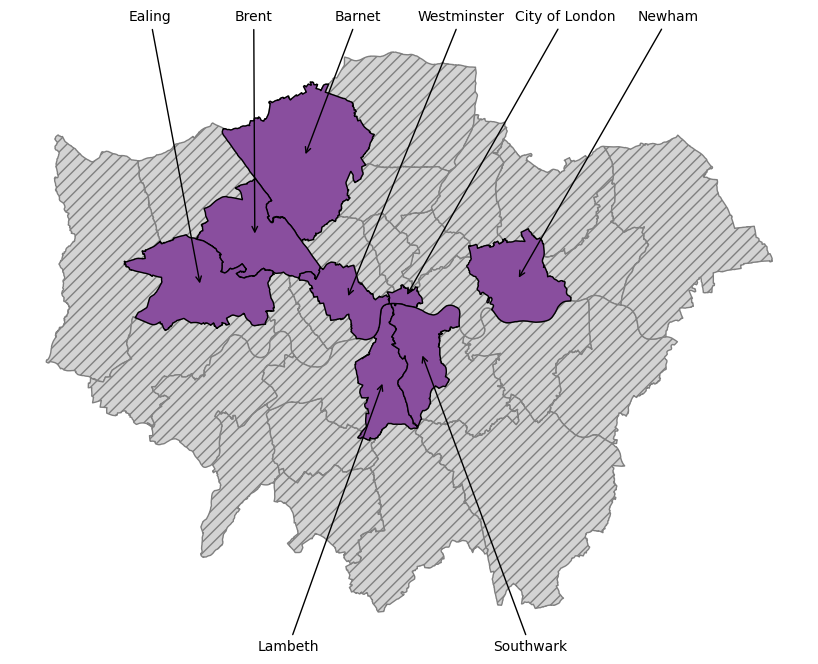

In [12]:
# Create a new column to indicate if the council is in the councils array
london_lad['highlight'] = london_lad['LAD24NM'].apply(lambda x: x in councils)

# Plot the GeoDataFrame
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
london_lad.plot(ax=ax, color='lightgrey', edgecolor='grey', hatch="///")  # Default color for all areas
london_lad[london_lad['highlight']].plot(ax=ax, color="#894e9e", edgecolor='black')  # Highlighted councils

# # add scatter of comments - comment out to get map without scatter 
# ax.scatter(
#     comment_gdf['lon'],
#     comment_gdf['lat'],
#     s=10,
#     color="#a0e8ef",
#     alpha=0.2,
#     label='Comments'
# )  

def annotate_side(df, side):
    # Sort the df by coordinate axis to get label order
    if side in ['left', 'right']:
       df = df.sort_values(by='centroid_y')  # south → north
    else:  # 'top' or 'bottom'
        df = df.sort_values(by='centroid_x')  # west → east
    
    n = len(df)
    if side in ['left', 'right']:
        # evenly space labels vertically
        y_positions = np.linspace(miny, maxy, n + 2)[1:-1]
        for i, (idx, row) in enumerate(df.iterrows()):
            cx, cy = row['centroid_x'], row['centroid_y']
            if side == 'left':
                lx, ly = minx - x_margin, y_positions[i]
                ha, va = 'right', 'center'
            else:  # right
                lx, ly = maxx + x_margin, y_positions[i]
                ha, va = 'left', 'center'

            ax.annotate(
                row['LAD24NM'],
                xy=(cx, cy),
                xytext=(lx, ly),
                textcoords='data',
                arrowprops=dict(arrowstyle='->', color='black', lw=1),
                fontsize=10,
                ha=ha,
                va=va,
                color='black'
            )
    else:
        # evenly space labels horizontally
        x_positions = np.linspace(minx, maxx, n + 2)[1:-1]
        for i, (idx, row) in enumerate(df.iterrows()):
            cx, cy = row['centroid_x'], row['centroid_y']
            if side == 'top':
                lx, ly = x_positions[i], maxy + y_margin
                ha, va = 'center', 'bottom'
            else:  # bottom
                lx, ly = x_positions[i], miny - y_margin
                ha, va = 'center', 'top'

            ax.annotate(
                row['LAD24NM'],
                xy=(cx, cy),
                xytext=(lx, ly),
                textcoords='data',
                arrowprops=dict(arrowstyle='->', color='black', lw=1),
                fontsize=10,
                ha=ha,
                va=va,
                color='black'
            )

for side, group in highlighted.groupby('side'):
    annotate_side(group, side)

ax.set_axis_off()

plt.savefig("../results/figures/just_london_councils_highlighted.png", dpi=500)
plt.show()

### Local authority barchart 
Plot stacked vertical bar chart showing the number of applications and the proportion receiving comments. 

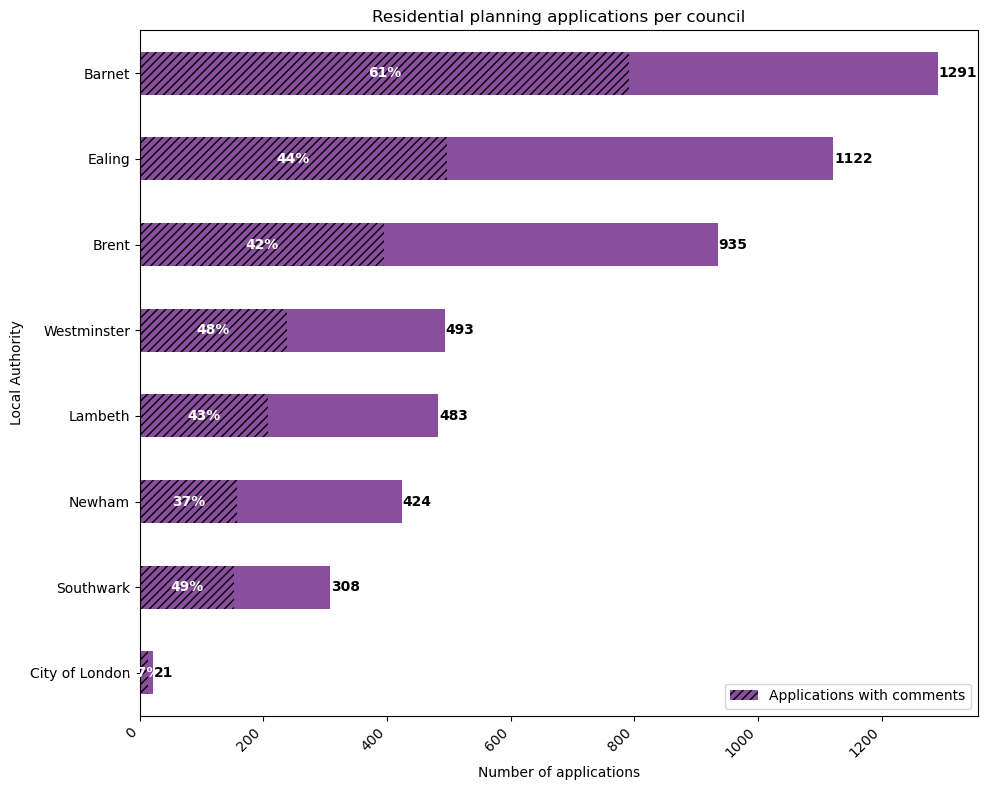

In [13]:
# make a copy to avoid modifying original
df = unique_app_counts.copy()

# compute the remainder (total minus subset). Clip to 0 to avoid negatives if data odd.
df['no_applications_remaining'] = (df['no_applications'] - df['no_applications_with_comments']).clip(lower=0)

# plot stacked bars: first the subset, then the remainder so subset is at the left of the bar
ax = df.plot.barh(
    x='council',
    y=['no_applications_with_comments', 'no_applications_remaining'],
    stacked=True,
    figsize=(10, 8),
    title='Residential planning applications per council',
    ylabel='Local Authority',
    xlabel='Number of applications',
    color=["#894e9e", "#894e9e"]  # same base color; we'll hatch the first
)

# patch list and counts
bars = ax.patches
n = len(df)

# apply hatching to the "with comments" bars (first n patches)
for i in range(n):
    bars[i].set_hatch('////')

# annotate:
# - bars[0..n-1] are the hashed (with_comments) segments
# - bars[n..2n-1] are the remainder segments
for i in range(n):
    bar_comments = bars[i]
    bar_remainder = bars[i + n]

    comments_w = bar_comments.get_width()
    remainder_w = bar_remainder.get_width()
    total_w = comments_w + remainder_w

    y = bar_comments.get_y() + bar_comments.get_height() / 2

    # --- 1) Hashed section percentage label (white) ---
    if total_w > 0:
        pct = comments_w / total_w * 100
        label = f'{pct:.0f}%'  # round to nearest whole %
    else:
        label = ''

    ax.text(
        bar_comments.get_x() + comments_w / 2,
        y,
        label,
        va='center',
        ha='center',
        fontsize=10,
        color='white',
        fontweight='bold'
    )

    # --- 2) Total label to the right ---
    ax.text(
        bar_remainder.get_x() + remainder_w + 1,
        y,
        f'{int(total_w)}',
        va='center',
        ha='left',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

# Only show legend for the hatched (with comments) section
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend([handles[0]], ['Applications with comments'], loc='lower right')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("../results/figures/bar_applications_per_council.png", dpi=500)
plt.show()


### Histogram of number of comments per planning application 

In [14]:
# format the application_df by adding comment counts
app_count = comment_df.groupby('application_id')['id'].count().reset_index()
app_count.columns = ['application_id', 'comment_count']

application_df = application_df.merge(app_count, left_on='lpa_app_no', right_on='application_id', how='left')
application_df['comment_count'] = application_df['comment_count'].fillna(0).astype(int)
application_df.drop(columns=['application_id'], inplace=True)

application_df = ppf.format_df(application_df)

In [17]:
application_df = ppf.create_decision_outcomes(application_df, completion_date_col_name='decision_date')

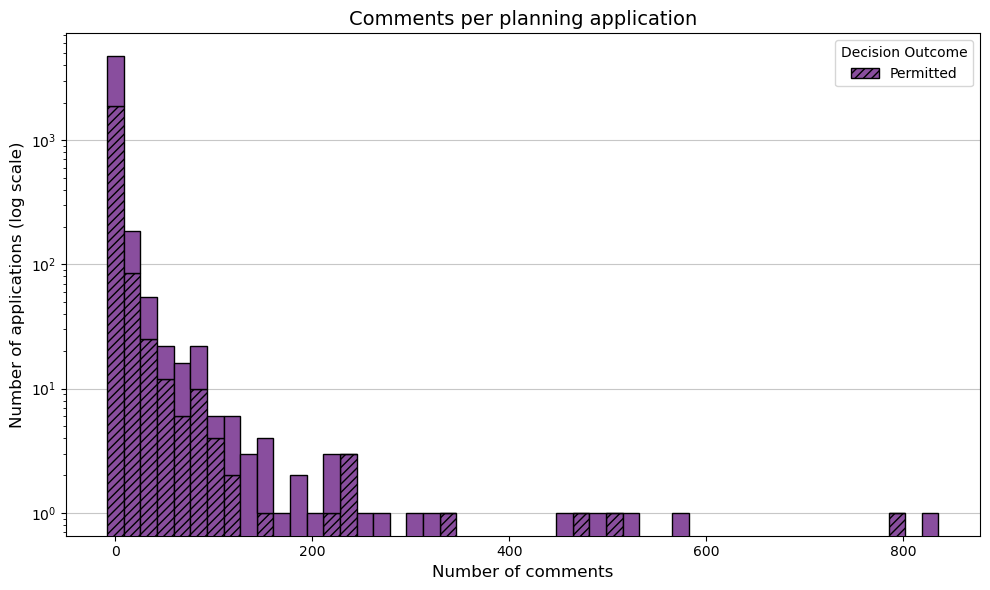

In [18]:
plt.figure(figsize=(10,6))

# Split data into two categories
permitted = application_df.loc[application_df['outcome'] == 'Permitted', 'comment_count']
not_permitted = application_df.loc[application_df['outcome'] != 'Permitted', 'comment_count']

# Common parameters
color = "#894e9e"
bins = 50

# Plot both datasets *in one call* for stacking
counts, bins, patches = plt.hist(
    [not_permitted, permitted],
    bins=bins,
    stacked=True,
    color=[color, color],
    edgecolor='black',
    alpha=1,
    align='left',
    label=['Permitted'],
    zorder=3
)

# Apply hatching only to the 'Permitted' bars (second group)
for patch in patches[0]:  # second dataset (index 1)
    patch.set_hatch('////')

# Log scale and labels
plt.yscale('log')
plt.title('Comments per planning application', fontsize=14)
plt.xlabel('Number of comments', fontsize=12)
plt.ylabel('Number of applications (log scale)', fontsize=12)
plt.grid(axis='y', alpha=0.7, zorder=0)
plt.legend(title='Decision Outcome')
plt.tight_layout()
plt.savefig("../results/figures/hist_comments_per_application_permitted.png", dpi=500)
plt.show()

### Applications and comments by residential build type 

In [19]:
esf = ElasticSearchFncs()
esf.check_connection()

Connected to Elastic Search


In [20]:
pld_df = esf.res_units_x_query(min_res_units=1, since_year="01/01/2021", to_year="01/05/2025")

In [21]:
pld_df = ppf.format_df(pld_df)
pld_df = ppf.add_housing_type(pld_df)

application_df = pd.merge(application_df, pld_df[['lpa_app_no', 'housing_type']], left_on='lpa_app_no', right_on='lpa_app_no', how='left')

In [ ]:
# check the mean includes applications with 0 comments 
application_df.groupby('housing_type')['comment_count'].agg(['mean', 'count'])

,mean,count
housing_type,,
Market housing,4.317213,4363
Mixed affordable housing,18.506173,243
Mixed social housing,38.770833,48
Other,2.670732,82
Self-build housing,4.242105,285
Social housing,7.544444,90


In [29]:
application_df.columns

Index(['lpa_app_no', 'valid_date', 'decision_date', 'borough',
       'total_no_proposed_residential_units', 'total_no_affordable_units',
       'site_area', 'habitable_rooms_density', 'pp_id', 'uprn', 'status',
       'decision', 'street_name', 'site_name', 'site_number', 'polygon',
       'wgs84_polygon', 'description', 'comment_count', 'outcome',
       'housing_type'],
      dtype='object')

<Figure size 1000x800 with 0 Axes>

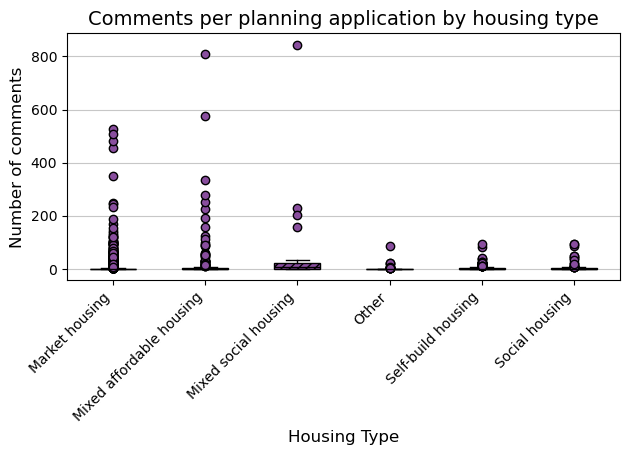

In [37]:
# box plot of comments per application by housing type
plt.figure(figsize=(10,8))
color = "#894e9e"
bp = application_df.boxplot(
    column='comment_count',
    by='housing_type',
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor=color, color='black', hatch='////'),
    medianprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(markerfacecolor=color, markeredgecolor='black'),
    zorder=3
)   

plt.title('Comments per planning application by housing type', fontsize=14)
plt.suptitle('')  # Remove the automatic 'Boxplot grouped by ...' title
plt.xticks(rotation=45, ha='right')
plt.xlabel('Housing Type', fontsize=12)
plt.ylabel('Number of comments', fontsize=12)
plt.grid(axis='y', alpha=0.7, zorder=0)
plt.tight_layout()
# plt.savefig("../results/figures/boxplot_comments_per_application_housing_type.png", dpi=500)
plt.show()

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_58156/1091408753.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(housing_types))


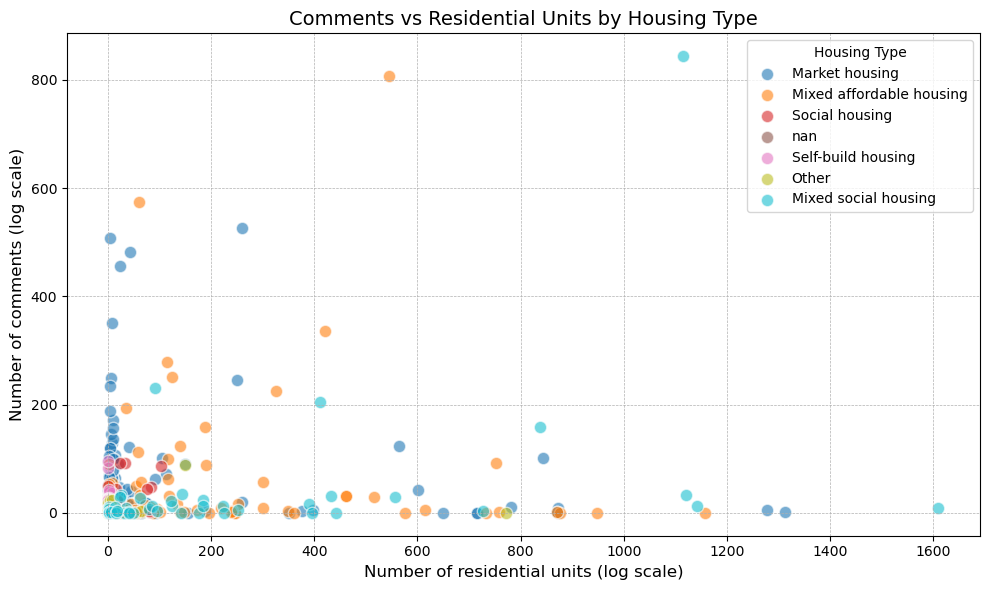

In [31]:
# scatterof comments vs residential units colour coded by housing type
plt.figure(figsize=(10,6))
housing_types = application_df['housing_type'].unique()
colors = plt.cm.get_cmap('tab10', len(housing_types))
for i, housing_type in enumerate(housing_types):
    subset = application_df[application_df['housing_type'] == housing_type]
    plt.scatter(
        subset['total_no_proposed_residential_units'],
        subset['comment_count'],
        color=colors(i),
        label=housing_type,
        alpha=0.6,
        edgecolors='w',
        s=80
    )
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Number of residential units (log scale)', fontsize=12)
plt.ylabel('Number of comments (log scale)', fontsize=12)
plt.title('Comments vs Residential Units by Housing Type', fontsize=14)
plt.legend(title='Housing Type')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
# plt.savefig("../results/figures/scatter_comments_vs_res_units_housing_type.png", dpi=500)
plt.show()

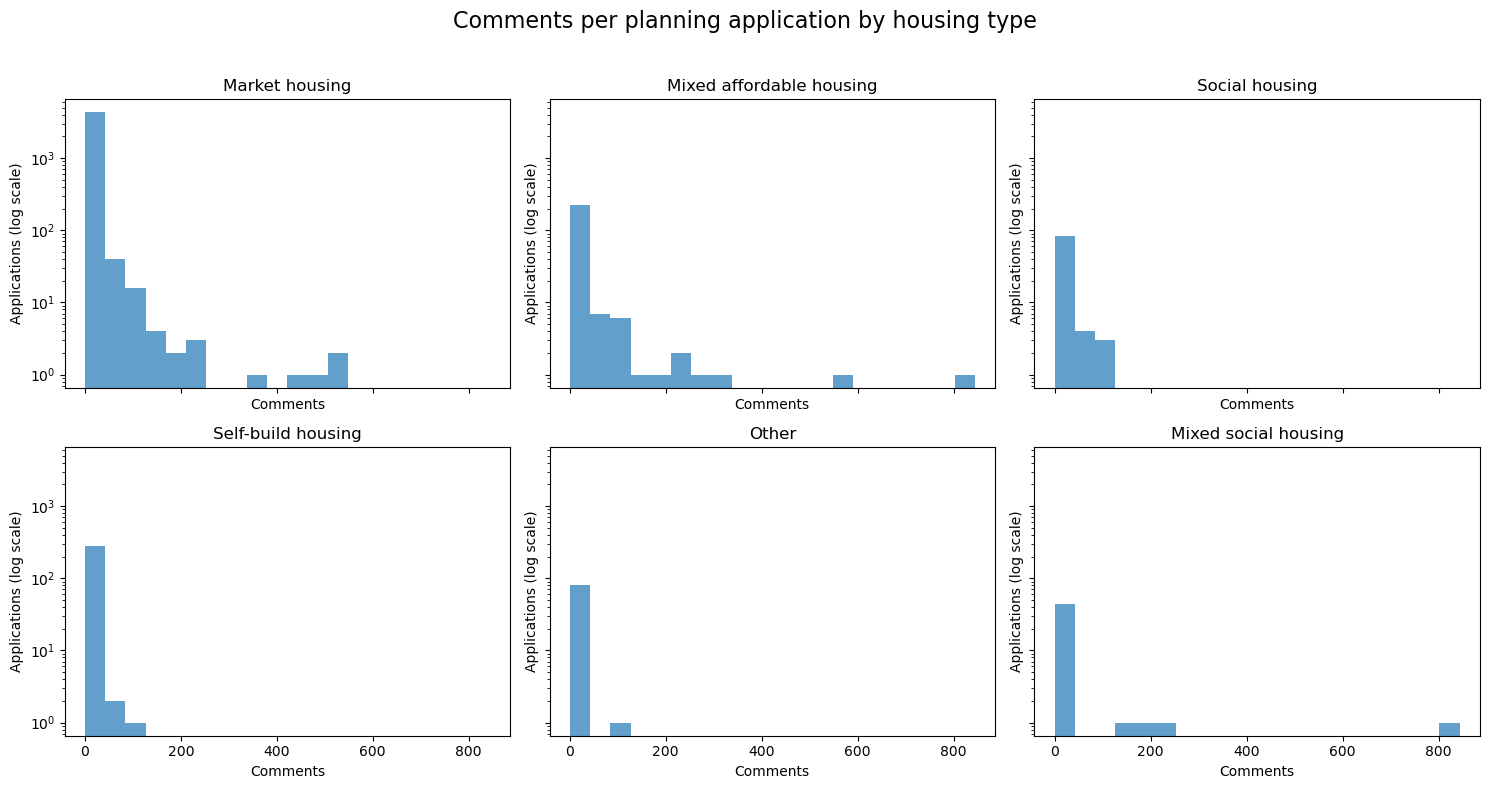

In [27]:
# Unique housing types
housing_types = application_df['housing_type'].dropna().unique()
n_types = len(housing_types)

# Global bins for consistent widths
all_counts = application_df['comment_count'].dropna()
bins = np.linspace(all_counts.min(), all_counts.max(), 21)

# Grid layout (e.g., 3 columns)
cols = 3
rows = math.ceil(n_types / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4), sharex=True, sharey=True)
axes = axes.flatten()  # easy indexing

for ax, ht in zip(axes, housing_types):
    subset = application_df.loc[
        application_df['housing_type'] == ht,
        'comment_count'
    ].dropna()

    ax.hist(subset, bins=bins, alpha=0.7)
    ax.set_title(ht)
    ax.set_yscale('log')
    ax.set_xlabel('Comments')
    ax.set_ylabel('Applications (log scale)')

# Hide any unused axes if housing_types isn't a perfect grid
for ax in axes[len(housing_types):]:
    ax.set_visible(False)

plt.suptitle('Comments per planning application by housing type', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
